In [1]:
import scanpy as sc
import pandas as pd
import numpy as np
import random
from scipy import sparse

In [2]:
adata = sc.read_h5ad("/project/imoskowitz/yubin/1-sc_practice/Data/SmoNull_Brain_system.h5ad")

In [17]:
adata

AnnData object with n_obs × n_vars = 38311 × 33696
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'Condition', 'Library.ident', 'Sample', 'Replicate', 'percent.mt', 'nCount_SCT', 'nFeature_SCT', 'SCT_snn_res.0.1', 'seurat_clusters', 'doublet_finder', 'doublet_status', 'S.Score', 'G2M.Score', 'Phase', 'old.ident', 'SCT_snn_res.1', 'SCT_snn_res.4', 'Extended_mouse_gastrulation_label', 'System', 'ClusterSystem', 'total_counts', 'size_factors', 'Celltype', 'leiden_0_25_log1p', 'leiden_0_25_scran', 'leiden_0_25_pearson', 'leiden_0_5_log1p', 'leiden_0_5_scran', 'leiden_0_5_pearson', 'leiden_1_log1p', 'leiden_1_scran', 'leiden_1_pearson', 'leiden_2_log1p', 'leiden_2_scran', 'leiden_2_pearson', 'leiden_3_log1p', 'leiden_3_scran', 'leiden_3_pearson', 'leiden_5_log1p', 'leiden_5_scran', 'leiden_5_pearson', 'manual_celltype_annotation'
    var: 'features', 'highly_variable_log1p', 'highly_variable_nbatches_log1p', 'highly_variable_intersection_log1p', 'mean', 'std', 'means', 'variances', 'r

In [26]:
# Display the count for each cell type and by condition (manually labeled)
pd.crosstab(adata.obs["manual_celltype_annotation"], adata.obs["Condition"])

Condition,Control,SmoNull
manual_celltype_annotation,,
Forebrain,3419,2910
Hindbrain,4502,6505
Midbrain,3220,3663
Midline,4127,68


Pseudobulk steps:

0. Choose a cluster/celltype
1. Group by Condition + replicate
2. Find total of gene count within the group for each gene (axis = 0)
3. Create a new anndata that stores the total count, as well as gene name. Should have format like this:

Condition + replicate| Gene1 | Gene 2 | ... | Gene n
---------------------|-------|--------|-----|--------
Control_1 | 0 | 1 | ... | 2
Smo_null | 0 | 100 | ... | 23

4. Make sure you include metadatas for obs such as the cell type, cluster, condition, replicate, etc

In [19]:
print(len(adata[adata.obs["Condition"]=="Control"].obs["Sample"].cat.categories))
print(len(adata[adata.obs["Condition"]=="SmoNull"].obs["Sample"].cat.categories))

3
3


In [31]:
adata[adata.obs["Sample"] == "Sample1"].obs.Condition.unique()

['Control']
Categories (1, object): ['Control']

In [35]:
[adata.obs["Condition"].iloc[0]]

['Control']

In [19]:
# Convert X to raw
adata.X = adata.layers["raw_counts"]

In [20]:
hindbrain_subset = adata[adata.obs.manual_celltype_annotation == "Hindbrain"]

In [21]:
# Since each sample is a unique condition + rep, we will loop over this
hindbrain_pbs = []

for sample in adata.obs["Sample"].unique():
    samp_cell_subset = hindbrain_subset[hindbrain_subset.obs['Sample'] == sample]

    count = samp_cell_subset.X.sum(axis=0)
    if isinstance(count, np.matrix):
        count = np.asarray(count)
    if sparse.issparse(count):
        count = count.A  # or use sparse matrix as appropriate
    rep_adata = sc.AnnData(X=count, var=samp_cell_subset.var.copy())
    
    # Now we add some metadata
    rep_adata.obs_names = [samp_cell_subset.obs["Condition"].iloc[0] + "_" + samp_cell_subset.obs["Replicate"].iloc[0]]
    rep_adata.obs["Condition"] = samp_cell_subset.obs["Condition"].iloc[0]
    rep_adata.obs["Replicate"] = samp_cell_subset.obs["Replicate"].iloc[0]
    rep_adata.obs["CellType"] = ["Hindbrain"]
    hindbrain_pbs.append(rep_adata)


    

In [24]:
hindbrain_pb = sc.concat(hindbrain_pbs)

In [25]:
hindbrain_pb.X

array([[323.,  18.,   6., ...,   0.,   0., 233.],
       [599.,  19.,  15., ...,   0.,   0., 447.],
       [471.,  17.,   7., ...,   0.,   0., 249.],
       [593.,  40.,  17., ...,   0.,   0., 423.],
       [324.,  20.,  12., ...,   0.,   0., 106.],
       [780.,  32.,  20., ...,   0.,   0., 452.]], shape=(6, 33696))

In [9]:
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats

In [10]:
counts = pd.DataFrame(data = hindbrain_pb.X, columns = hindbrain_pb.var_names)

In [26]:
counts.max()

Xkr4                  780.0
Gm1992                 40.0
Gm19938                20.0
Gm37381                 3.0
Rp1                    15.0
                      ...  
ENSMUSG00000095523      0.0
ENSMUSG00000095475      0.0
ENSMUSG00000094855      0.0
ENSMUSG00000095019      0.0
ENSMUSG00000095041    452.0
Length: 33696, dtype: float64

In [27]:
dds = DeseqDataSet(counts = counts, metadata=hindbrain_pb.obs, design='~Condition')

In [28]:
sc.pp.filter_genes(dds, min_cells=1)

In [29]:
dds

AnnData object with n_obs × n_vars = 6 × 26519
    obs: 'Condition', 'Replicate', 'CellType'
    var: 'n_cells'
    obsm: 'design_matrix'

In [30]:
dds.deseq2()

Fitting size factors...
... done in 0.01 seconds.



Using None as control genes, passed at DeseqDataSet initialization


Fitting dispersions...
... done in 2.93 seconds.

Fitting dispersion trend curve...
... done in 0.57 seconds.

Fitting MAP dispersions...
... done in 3.40 seconds.

Fitting LFCs...
... done in 2.48 seconds.

Calculating cook's distance...
... done in 0.02 seconds.

Replacing 0 outlier genes.



In [31]:
dds

AnnData object with n_obs × n_vars = 6 × 26519
    obs: 'Condition', 'Replicate', 'CellType', 'size_factors', 'replaceable'
    var: 'n_cells', '_normed_means', 'non_zero', '_MoM_dispersions', 'genewise_dispersions', '_genewise_converged', 'fitted_dispersions', 'MAP_dispersions', '_MAP_converged', 'dispersions', '_outlier_genes', '_LFC_converged', 'replaced', 'refitted', '_pvalue_cooks_outlier'
    uns: 'trend_coeffs', 'disp_function_type', '_squared_logres', 'prior_disp_var'
    obsm: 'design_matrix', '_mu_LFC', '_hat_diagonals'
    varm: 'LFC'
    layers: 'normed_counts', '_mu_hat', 'cooks'

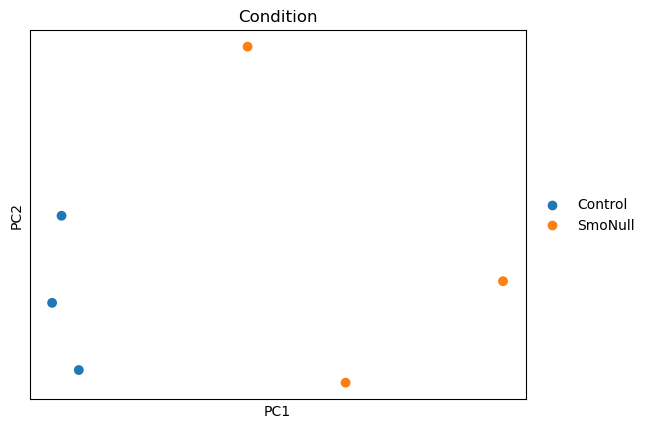

In [33]:
sc.tl.pca(dds)
sc.pl.pca(dds, color = "Condition", size=200)

In [34]:
stat_res = DeseqStats(dds, n_cpus=8, contrast=("Condition", "Control", "SmoNull"))

In [35]:
stat_res.summary()

Running Wald tests...


Log2 fold change & Wald test p-value: Condition Control vs SmoNull
                      baseMean  log2FoldChange     lfcSE      stat    pvalue  \
Xkr4                489.923797       -0.173431  0.145949 -1.188297  0.234717   
Gm1992               23.294824       -0.051471  0.418365 -0.123029  0.902084   
Gm19938              12.049165       -0.394001  0.563348 -0.699392  0.484307   
Gm37381               0.504649       -2.149420  3.358921 -0.639914  0.522229   
Rp1                   7.060131       -0.226572  0.788207 -0.287453  0.773765   
...                        ...             ...       ...       ...       ...   
ENSMUSG00000095500    0.375806        0.649481  3.541075  0.183413  0.854474   
Csprs                 0.132808       -0.312305  4.427542 -0.070537  0.943766   
ENSMUSG00000096808    0.885288       -1.580823  2.208785 -0.715698  0.474178   
ENSMUSG00000095742   10.259770        0.051717  0.587884  0.087972  0.929899   
ENSMUSG00000095041  299.150421       -0.544670  0.257

... done in 9.47 seconds.



In [ ]:
de = stat_res.results_df

In [37]:
de

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
Xkr4,489.923797,-0.173431,0.145949,-1.188297,0.234717,0.441765
Gm1992,23.294824,-0.051471,0.418365,-0.123029,0.902084,0.953190
Gm19938,12.049165,-0.394001,0.563348,-0.699392,0.484307,0.689272
Gm37381,0.504649,-2.149420,3.358921,-0.639914,0.522229,NaN
Rp1,7.060131,-0.226572,0.788207,-0.287453,0.773765,NaN
...,...,...,...,...,...,...
ENSMUSG00000095500,0.375806,0.649481,3.541075,0.183413,0.854474,NaN
Csprs,0.132808,-0.312305,4.427542,-0.070537,0.943766,NaN
ENSMUSG00000096808,0.885288,-1.580823,2.208785,-0.715698,0.474178,NaN
ENSMUSG00000095742,10.259770,0.051717,0.587884,0.087972,0.929899,0.966723


In [39]:
de.to_csv("DEG_Hindbrain_Control_vs_SmoNull")

In [40]:
pwd()

'/project/imoskowitz/yubin'